## How to Build a Network

This is a simplified example that demonstrates how to extract a single paper, try a few relationship identification algorithms (co-occurence, relational term, or BioBERT), and visualize the resulting network. First, let's load DancePartner and pandas.

In [1]:
import DancePartner as dance
import pandas as pd

/Users/degn400/.virtualenvs/DancePartner/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-09-18 16:34:13 WE45748 metapub.config[71640] WARNING NCBI_API_KEY was not set.


### Extract Terms

You can use a list of terms, or SciSpaCy to identify terms. Here, let's define a list. All text in the publication will be changed to lowercase, and all non-alphanumeric character removed.

In [2]:
terms = ['ces1c', 'ifnb', 'rtv', 'cxcl10', 'lopinavir', 'lpv', 'hdpp4', 'mx1', 'ritonavir', 'dpp4', 'remdesivir', 'ip10']

### Define Synonyms

We could use the `.make_synonym_table()` function to construct a synonym table, but here we are presenting a simplified case with an individual paper. The synonym list simply needs to be a table with four columns - DancePartnerID (any number denoting a unique case), ID (a UniProt, Ensembl, etc. identifier - can be blank in this case), Synonym (this can be our terms), and Type (whether it is a gene product, lipid, or metabolite)

In [3]:
Synonyms = pd.DataFrame({
    "DancePartnerID": [x for x in range(len(terms))],
    "ID": "",
    "Synonym": terms,
    "Type": ["gene product", "gene product", "metabolite", "gene product", "metabolite", "metabolite", "gene product", "geme product", "metabolite", "gene product", "metabolite", "gene product"]

})

Synonyms

,DancePartnerID,ID,Synonym,Type
0,0,,ces1c,gene product
1,1,,ifnb,gene product
2,2,,rtv,metabolite
3,3,,cxcl10,gene product
4,4,,lopinavir,metabolite
5,5,,lpv,metabolite
6,6,,hdpp4,gene product
7,7,,mx1,geme product
8,8,,ritonavir,metabolite
9,9,,dpp4,gene product


### Identify Terms in Text

To find terms in text, use `.find_terms_in_papers()`. To the papers argument, supply the folder with the text files in it, and provide the list of terms for the terms argument.


In [4]:
find_terms = dance.find_terms_in_papers(
    papers = "single_example",
    terms = terms
)
find_terms

,paper_id,term_1,term_2,id,sentence_index,segment_length,segment
40,Example,ifnb,ip10,Example,99,231,similarly a single dose of ifnb signicantly in...
58,Example,lpv,rtv,Example,338,216,lpv 10 mmstock and rtv 10 mm stock were simila...
57,Example,lpv,ifnb,Example,333,185,to better understand the antiviral activities ...
56,Example,rtv,ifnb,Example,333,185,to better understand the antiviral activities ...
55,Example,lpv,rtv,Example,333,185,to better understand the antiviral activities ...
...,...,...,...,...,...,...,...
9,bert_results,ip10,cxcl10,bert_results,0,31,06exampleip10cxcl10example3
10,bert_results,lopinavir,rtv,bert_results,0,85,mbination lopinavir term2 and interf09999634...
11,bert_results,dpp4,hdpp4,bert_results,0,30,06exampledpp4hdpp4example3
6,bert_results,ritonavir,rtv,bert_results,0,152,emdesivirritonavirexample066term1term2fcacy of...


### Sentence Co-Occurrence

For the simplest model, sentence co-occurrence only requires terms to co-occur in a sentence to be considered related. We simply need the dataframe of found terms and the dataframe of synonyms. 

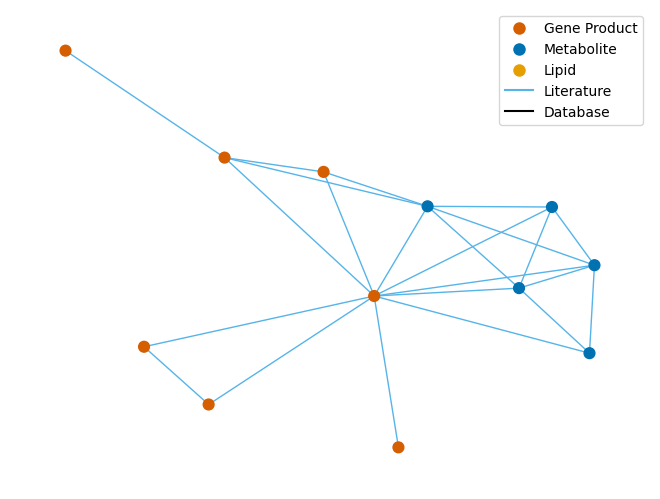

In [5]:
cooccurrence = dance.run_cooccurrence(found_terms = find_terms, synonyms = Synonyms)
dance.visualize_network(cooccurrence, edge_weight = 1, node_size = 60)

### Relational Term

This approach ensures that a relationship word (e.g. binds, connects, etc.) exists between terms to be considered related. The inputs are the same as co-occurence. In this specific case, there isn't much difference between the two.

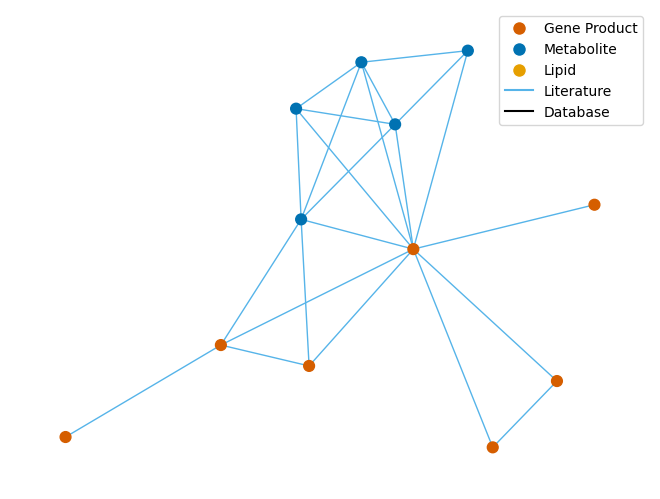

In [6]:
relational_term = dance.run_cooccurrence(found_terms = find_terms, synonyms = Synonyms, relational_term = True)
dance.visualize_network(cooccurrence, edge_weight = 1, node_size = 60)

## BioBERT

Finally, let's try to run the BioBERT algorithm. Make sure to download the model from: https://huggingface.co/david-degnan/BioBERT-RE, and place it in a folder called "bioert" at the top level. At a minimum, the config.json, pytorch_model.bin, and training_args.bin files are needed.

In [7]:
biobert = dance.run_bert(input_path = "./single_example/found_terms.csv",
                         model_path = "../biobert", # Update to the path of your BERT model if necessary. We recommend placing biobert in the top directory.
                         output_directory = "single_example",
                         segment_col_name = "segment",
                         use_cpu = True)

If that step ran correctly, then you can now extract the BERT results.

In [8]:
# Pull all identified relationships and filter to the confirmed ones
BERT = pd.read_table("./single_example/bert_results.txt")
TrueBERT = BERT[BERT["True Positive"] >= 0.5].reset_index(drop = True)
TrueBERT

,paper_id,term_1,term_2,id,sentence_index,segment_length,Term1,Term2,Sentence,True Negative,True Positive
0,Example,ifnb,lpv,Example,2,97,@TERM$1,@TERM$2,here we show thatremdesivir rdv and @TERM$1 ...,0.087352,0.912648
1,Example,ifnb,rtv,Example,2,97,@TERM$1,@TERM$2,here we show thatremdesivir rdv and @TERM$1 ...,0.011660,0.988340


Like before, we simply need to take the output and make a network table. Then that can be visualized.

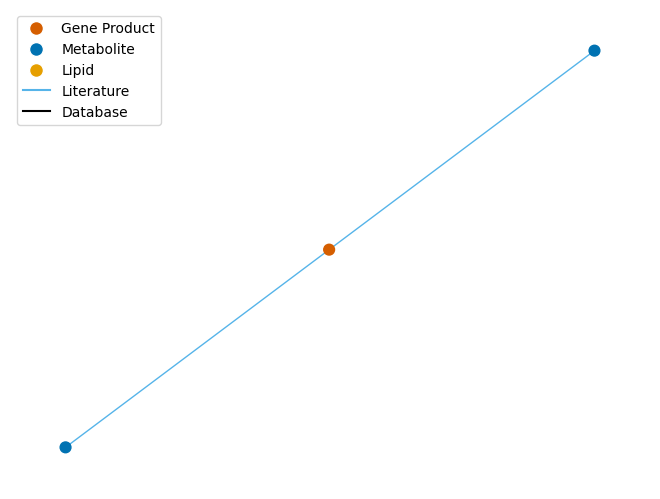

In [9]:
BioBERT = dance.build_network_table(TrueBERT, Synonyms)
dance.visualize_network(BioBERT, edge_weight = 1, node_size = 60)